# DSS5201 Group Project: Coffee Consumption, Preferences, and Spending

**Group Name:** Replace with your group name  
**Members:** Replace with member names and student IDs  
**Topic:** The Great American Coffee Taste Test (TidyTuesday 2024-05-14)

**Research question:** How are coffee drinking habits, brewing preferences, and self-rated coffee expertise associated with monthly coffee spending and willingness to pay among respondents in the coffee survey?


## 1. Introduction

This project uses the `coffee_survey.csv` data from TidyTuesday's **The Great American Coffee Taste Test** release. The survey was collected around an online coffee tasting event led by James Hoffmann and Cometeer in October 2023, then republished by TidyTuesday as a public data set for practice and analysis. The file contains 4,042 survey responses and 57 variables on demographics, brewing methods, favorite drinks, roast preferences, coffee expertise, and spending behavior.

We study whether higher coffee spending is associated with three related factors: daily consumption intensity, brewing and drink preferences, and self-rated coffee expertise. This question is well suited to the assignment because it can be answered with a focused set of descriptive visualizations. At the same time, the sample is self-selected and likely skews toward coffee enthusiasts, so the analysis should be interpreted as a profile of survey respondents rather than a representative picture of all American coffee drinkers.


In [26]:
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(
    style="whitegrid",
    context="talk",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
    },
)

plt.rcParams["font.family"] = "DejaVu Sans"

ROOT = Path.cwd()
LOCAL_DATA_PATH = ROOT / "data" / "coffee_survey.csv"
DATA_URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-05-14/coffee_survey.csv"

if LOCAL_DATA_PATH.exists():
    raw = pd.read_csv(LOCAL_DATA_PATH)
    data_source = str(LOCAL_DATA_PATH)
else:
    raw = pd.read_csv(DATA_URL)
    data_source = DATA_URL

print(f"Loaded {len(raw):,} rows and {raw.shape[1]} columns from: {data_source}")


Loaded 4,042 rows and 57 columns from: https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-05-14/coffee_survey.csv


## 2. Data Cleaning and Summary

To keep the notebook tightly aligned with the research question, we retained only variables needed for consumption frequency, work arrangement, brewing method, favorite drink, roast preference, expertise, monthly spending, and maximum willingness to pay. We standardized the order of categorical variables such as `cups` and `total_spend`, recoded work arrangement to shorter labels, and collapsed roast labels into three broader groups (`Light`, `Medium`, `Dark`) so that the final figures remain readable in a static HTML report. We also converted the willingness-to-pay bands into approximate numeric midpoints, which allows us to compare distributions in a boxplot while still acknowledging that the original responses were intervals.

Missing values are handled separately for each figure, because the assignment emphasizes a clean narrative rather than one single modeling sample. For the bubble chart, we additionally limit the display to the five most common brewing methods and the five most common favorite drinks, and we suppress combinations with fewer than 20 respondents so that the color scale is not dominated by unstable small cells. Because `brew` is a multi-select question, respondents can contribute to more than one brewing category in Figure 2; this figure should therefore be read as overlapping user profiles rather than mutually exclusive groups.


In [27]:
cups_order = ["Less than 1", "1", "2", "3", "4", "More than 4"]
cups_labels = ["<1 cup", "1 cup", "2 cups", "3 cups", "4 cups", ">4 cups"]

spend_order = ["<$20", "$20-$40", "$40-$60", "$60-$80", "$80-$100", ">$100"]

willing_midpoints = {
    "Less than $2": 1.5,
    "$2-$4": 3,
    "$4-$6": 5,
    "$6-$8": 7,
    "$8-$10": 9,
    "$10-$15": 12.5,
    "$15-$20": 17.5,
    "More than $20": 22.5,
}

wfh_map = {
    "I primarily work from home": "Home",
    "I do a mix of both": "Hybrid",
    "I primarily work in person": "In person",
}

roast_map = {
    "Light": "Light",
    "Nordic": "Light",
    "Blonde": "Light",
    "Medium": "Medium",
    "Dark": "Dark",
    "Italian": "Dark",
    "French": "Dark",
}

top_methods = [
    "Pour over",
    "Espresso",
    "French press",
    "Coffee brewing machine (e.g. Mr. Coffee)",
    "Pod/capsule machine (e.g. Keurig/Nespresso)",
]
method_labels = {
    "Pour over": "Pour over",
    "Espresso": "Espresso",
    "French press": "French press",
    "Coffee brewing machine (e.g. Mr. Coffee)": "Drip machine",
    "Pod/capsule machine (e.g. Keurig/Nespresso)": "Pod/capsule",
}

top_favorites = [
    "Pourover",
    "Latte",
    "Regular drip coffee",
    "Cappuccino",
    "Espresso",
]
favorite_labels = {
    "Pourover": "Pour-over",
    "Latte": "Latte",
    "Regular drip coffee": "Drip coffee",
    "Cappuccino": "Cappuccino",
    "Espresso": "Espresso",
}

coffee = raw.copy()
coffee["cups"] = pd.Categorical(coffee["cups"], categories=cups_order, ordered=True)
coffee["total_spend"] = pd.Categorical(coffee["total_spend"], categories=spend_order, ordered=True)
coffee["high_spend"] = coffee["total_spend"].isin(["$60-$80", "$80-$100", ">$100"])
coffee["wfh_clean"] = pd.Categorical(
    coffee["wfh"].map(wfh_map),
    categories=["Home", "Hybrid", "In person"],
    ordered=True,
)
coffee["roast_broad"] = pd.Categorical(
    coffee["roast_level"].map(roast_map),
    categories=["Light", "Medium", "Dark"],
    ordered=True,
)
coffee["most_willing_numeric"] = coffee["most_willing"].map(willing_midpoints)
coffee["expertise_band"] = pd.Categorical(
    pd.cut(
        coffee["expertise"],
        bins=[-0.1, 3, 6, 10],
        labels=["Low (0-3)", "Medium (4-6)", "High (7-10)"],
    ),
    categories=["Low (0-3)", "Medium (4-6)", "High (7-10)"],
    ordered=True,
)

fig1_df = coffee.dropna(subset=["cups", "total_spend", "wfh_clean"]).copy()
fig3_df = coffee.dropna(subset=["expertise_band", "most_willing_numeric", "roast_broad"]).copy()

brew_long = (
    coffee.loc[coffee["favorite"].isin(top_favorites), ["submission_id", "favorite", "high_spend", "total_spend", "brew"]]
    .assign(
        brew_list=lambda d: d["brew"].fillna("").str.split(",").apply(
            lambda values: [item.strip() for item in values if item.strip()]
        )
    )
    .explode("brew_list")
    .dropna(subset=["brew_list", "favorite", "total_spend"])
    .loc[lambda d: d["brew_list"].isin(top_methods)]
    .assign(
        brew_display=lambda d: pd.Categorical(
            d["brew_list"].map(method_labels),
            categories=[method_labels[m] for m in top_methods],
            ordered=True,
        ),
        favorite_display=lambda d: pd.Categorical(
            d["favorite"].map(favorite_labels),
            categories=[favorite_labels[f] for f in top_favorites],
            ordered=True,
        ),
    )
)

fig2_df = (
    brew_long.groupby(["brew_display", "favorite_display"], observed=True)
    .agg(
        respondents=("submission_id", "nunique"),
        high_spend_share=("high_spend", "mean"),
    )
    .reset_index()
    .query("respondents >= 20")
)

summary_table = pd.DataFrame(
    {
        "Metric": [
            "Raw survey responses",
            "Raw variables",
            "Figure 1 analytic sample",
            "Figure 2 rows after exploding brew selections",
            "Figure 3 analytic sample",
        ],
        "Value": [
            f"{len(raw):,}",
            raw.shape[1],
            f"{len(fig1_df):,}",
            f"{len(brew_long):,}",
            f"{len(fig3_df):,}",
        ],
    }
)

missingness = (
    raw[["cups", "wfh", "total_spend", "brew", "favorite", "expertise", "most_willing", "roast_level"]]
    .isna()
    .mean()
    .mul(100)
    .round(1)
    .rename("Missing %")
    .to_frame()
)

top_favorite_table = (
    raw["favorite"]
    .value_counts()
    .head(5)
    .rename_axis("Favorite drink")
    .reset_index(name="Responses")
)

brew_mentions = (
    raw["brew"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(5)
    .rename_axis("Brewing method")
    .reset_index(name="Mentions")
)

display(summary_table)
display(missingness)
display(top_favorite_table)
display(brew_mentions)


,Metric,Value
0,Raw survey responses,"4,042"
1,Raw variables,57
2,Figure 1 analytic sample,"3,463"
3,Figure 2 rows after exploding brew selections,"3,698"
4,Figure 3 analytic sample,"3,510"


,Missing %
cups,2.3
wfh,12.8
total_spend,13.1
brew,9.5
favorite,1.5
expertise,2.6
most_willing,13.2
roast_level,2.5


,Favorite drink,Responses
0,Pourover,1084
1,Latte,680
2,Regular drip coffee,442
3,Cappuccino,341
4,Espresso,330


,Brewing method,Mentions
0,Pour over,2295
1,Espresso,1518
2,French press,735
3,Other,677
4,Coffee brewing machine (e.g. Mr. Coffee),663


The summary tables show that missingness for the key analytical variables stays mostly in the low-to-moderate range, with `wfh`, `total_spend`, and `most_willing` each missing for about 13% of respondents. The descriptive distributions also suggest that the sample is heavily coffee-oriented: pour-over appears as the most common favorite drink, and manual or enthusiast brewing methods are highly visible. These patterns reinforce the need to discuss the results as relationships within a self-selected coffee community rather than a nationally representative sample.


## 3. Visualization

### Figure 1. Does higher monthly coffee spending mainly come from heavier daily consumption, and does this pattern look different across work arrangements?

This figure uses `cups`, `total_spend`, and `wfh_clean`. A faceted heatmap is ideal here because both main variables are ordered categories, and the panel structure allows us to compare the same relationship across home, hybrid, and in-person workers without adding a separate plot. Within each panel, rows are normalized to percentages so that the spending distribution remains comparable across consumption levels of very different sizes.


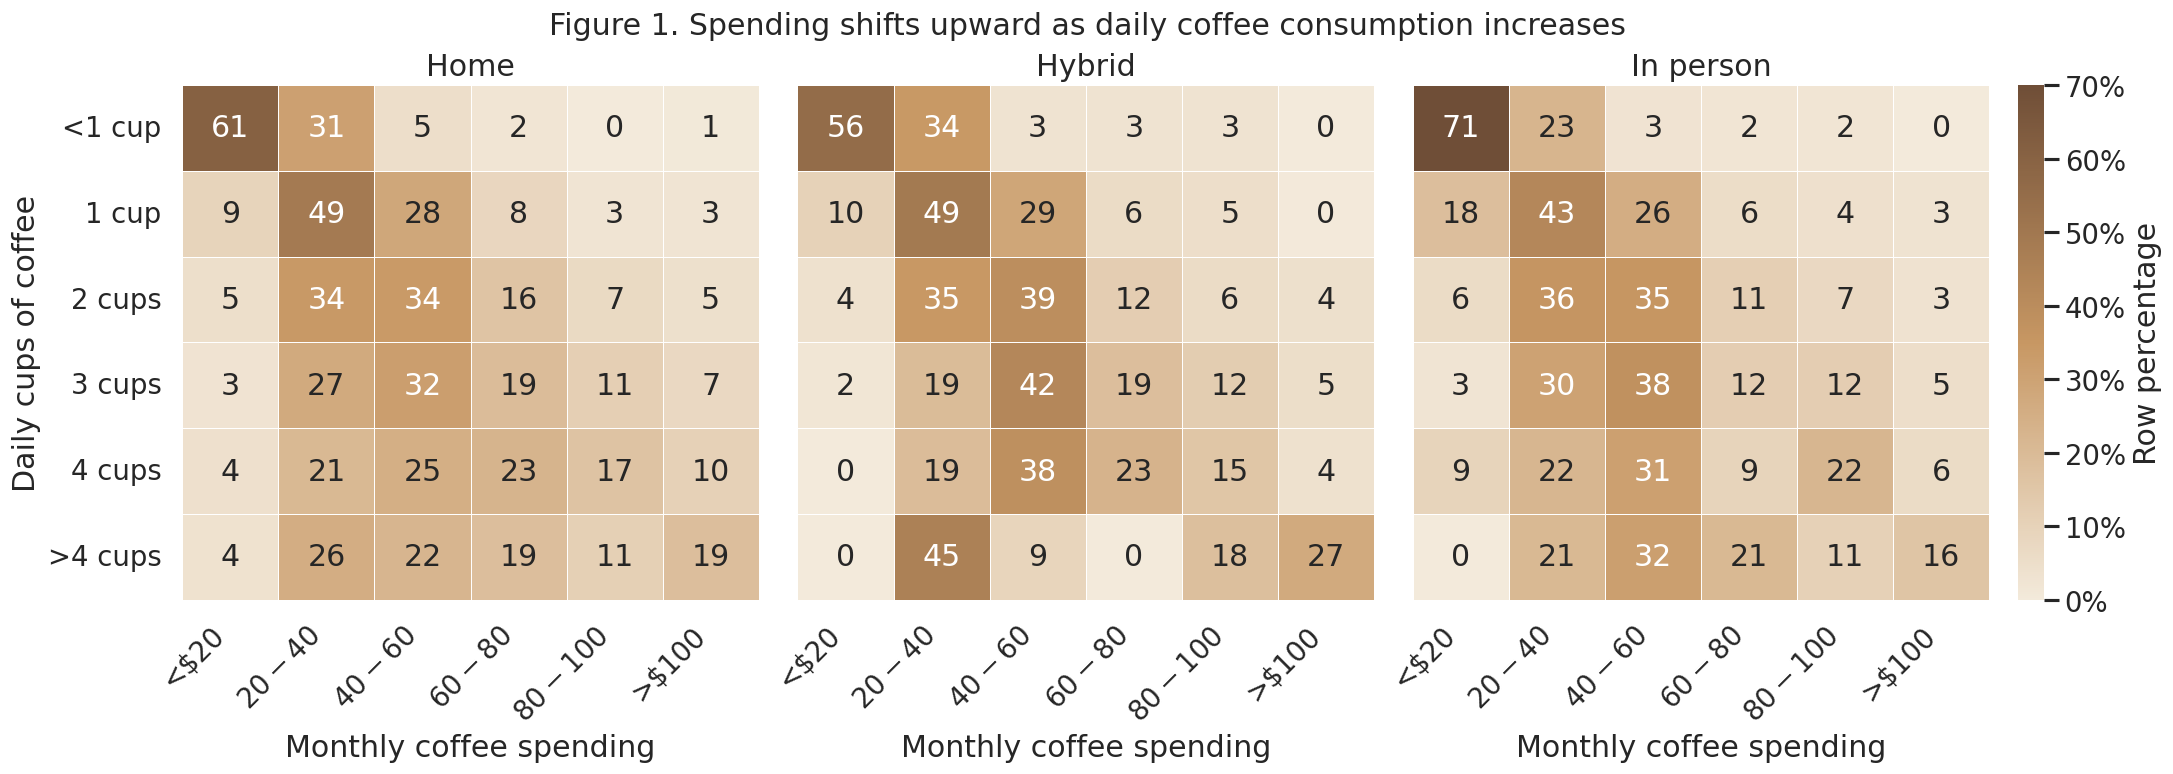

In [28]:
heatmap_palette = sns.blend_palette(["#f3eadb", "#c79763", "#6f4e37"], as_cmap=True)
heatmaps = {
    label: pd.crosstab(
        fig1_df.loc[fig1_df["wfh_clean"] == label, "cups"],
        fig1_df.loc[fig1_df["wfh_clean"] == label, "total_spend"],
        normalize="index",
    ).reindex(index=cups_order, columns=spend_order)
    for label in ["Home", "Hybrid", "In person"]
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, constrained_layout=True)

for ax, (label, table) in zip(axes, heatmaps.items()):
    heat = sns.heatmap(
        table,
        ax=ax,
        cmap=heatmap_palette,
        annot=(table * 100).round(0),
        fmt=".0f",
        linewidths=0.5,
        linecolor="white",
        vmin=0,
        vmax=0.70,
        cbar=ax is axes[-1],
        cbar_kws={"label": "Row percentage"},
    )
    ax.set_title(label)
    ax.set_xlabel("Monthly coffee spending")
    ax.set_ylabel("Daily cups of coffee" if ax is axes[0] else "")
    ax.set_yticklabels(cups_labels, rotation=0)
    ax.set_xticklabels(spend_order, rotation=45, ha="right")
    if ax is axes[-1]:
        heat.collections[0].colorbar.ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))

fig.suptitle("Figure 1. Spending shifts upward as daily coffee consumption increases", y=1.05, fontsize=18)
plt.show()


### Figure 2. Which brewing-method and favorite-drink combinations are most common among higher-spending respondents?

This figure combines `brew`, `favorite`, and `high_spend`. A bubble chart works well because it allows one chart to show both the size of each subgroup and its share of respondents in the upper monthly spending brackets (`$60-$80`, `$80-$100`, and `>$100`). Bubble size represents the number of respondents in a combination, while color shows the proportion of higher spenders; this makes the plot much more information-dense than a single bar chart.


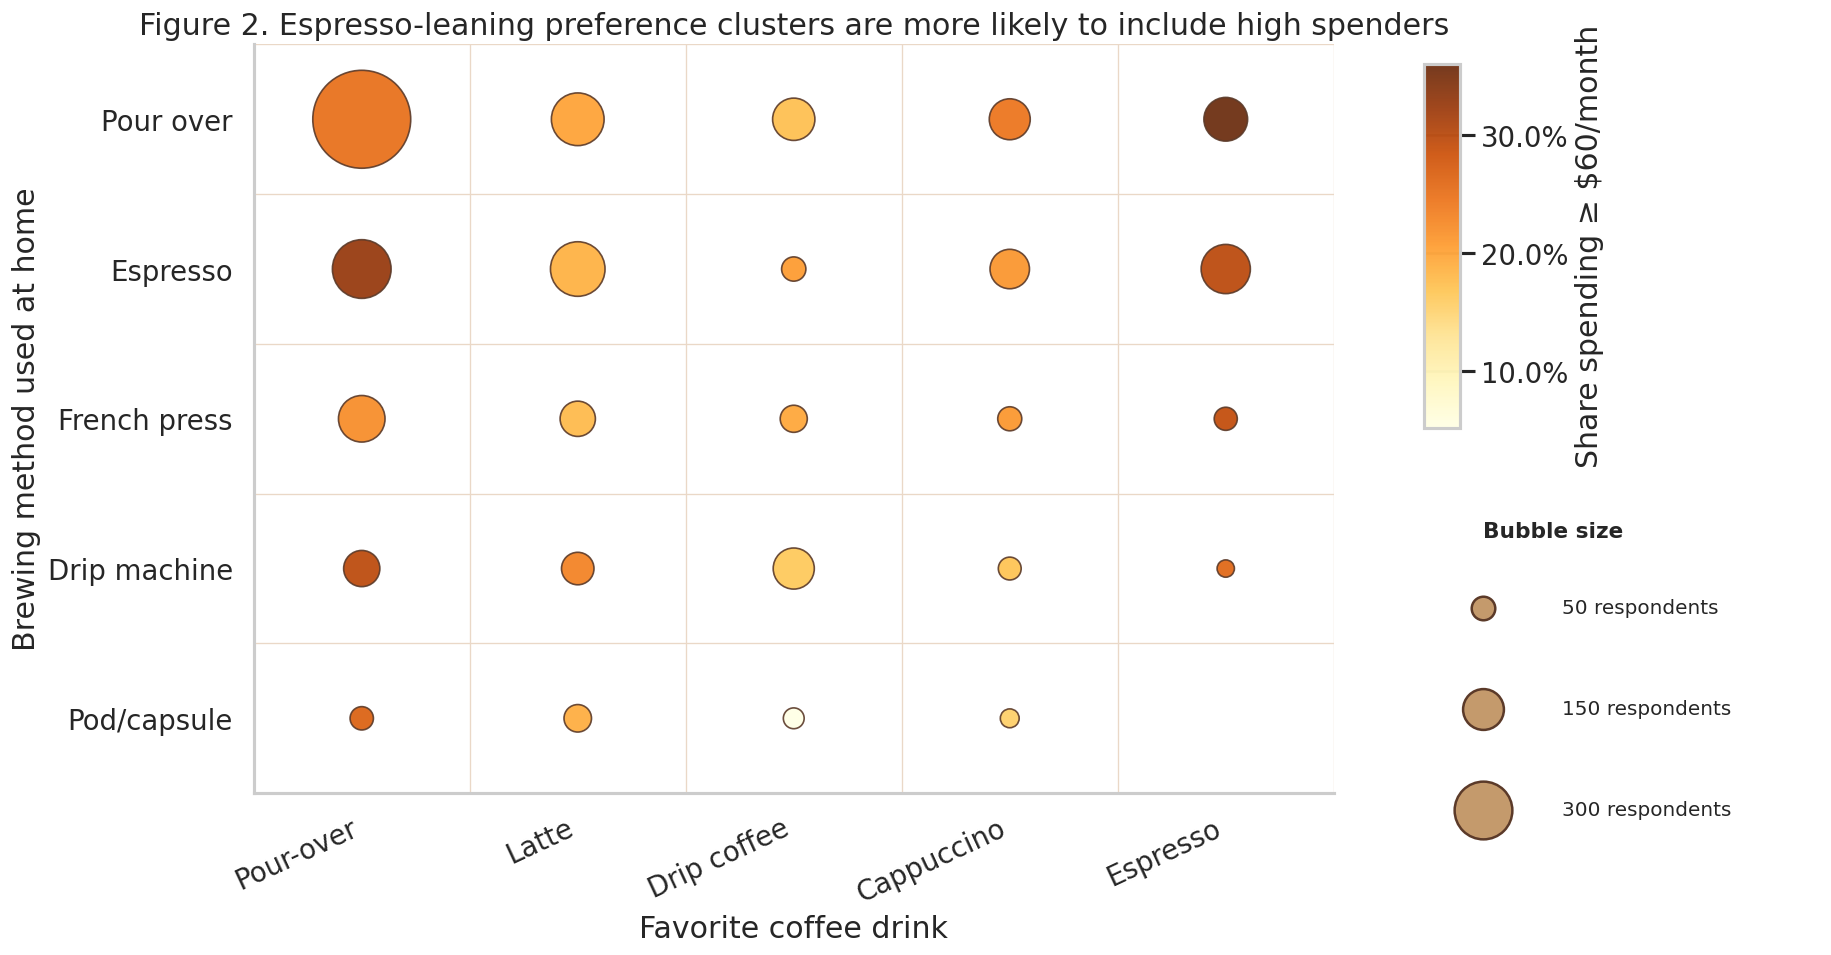

In [29]:
bubble = fig2_df.copy()
x_order = [favorite_labels[value] for value in top_favorites]
y_order = [method_labels[value] for value in top_methods]

bubble["x"] = bubble["favorite_display"].cat.codes
bubble["y"] = bubble["brew_display"].cat.codes

fig = plt.figure(figsize=(15, 8))
# Main axes with right margin for legends
ax = fig.add_axes([0.08, 0.12, 0.60, 0.78])

scatter = ax.scatter(
    bubble["x"],
    bubble["y"],
    s=bubble["respondents"] * 4,
    c=bubble["high_spend_share"],
    cmap=sns.color_palette("YlOrBr", as_cmap=True),
    edgecolors="#5b3a29",
    linewidths=1.0,
    alpha=0.9,
)

ax.set_xticks(range(len(x_order)))
ax.set_xticklabels(x_order, rotation=25, ha="right")
ax.set_yticks(range(len(y_order)))
ax.set_yticklabels(y_order)
ax.set_xlim(-0.5, len(x_order) - 0.5)
ax.set_ylim(-0.5, len(y_order) - 0.5)
ax.invert_yaxis()
ax.set_xlabel("Favorite coffee drink")
ax.set_ylabel("Brewing method used at home")
ax.set_title("Figure 2. Espresso-leaning preference clusters are more likely to include high spenders")

ax.set_xticks(np.arange(-0.5, len(x_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(y_order), 1), minor=True)
ax.grid(which="minor", color="#ead8c7", linewidth=0.8)
ax.grid(False)

# Vertical colorbar on the right (upper portion)
cbar_ax = fig.add_axes([0.73, 0.50, 0.02, 0.38])
cbar = fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label("Share spending ≥ $60/month")
cbar.ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))

# Bubble size legend on the right (lower portion)
legend_ax = fig.add_axes([0.73, 0.05, 0.22, 0.35])
legend_ax.set_axis_off()
for i, size in enumerate([50, 150, 300]):
    y_pos = 0.75 - i * 0.30
    legend_ax.scatter(0.15, y_pos, s=size * 4, c="#c49a6c", edgecolors="#5b3a29",
                      transform=legend_ax.transAxes, clip_on=False)
    legend_ax.text(0.35, y_pos, f"{size} respondents", va="center",
                   transform=legend_ax.transAxes, fontsize=12)
legend_ax.text(0.15, 0.95, "Bubble size", fontweight="bold", va="bottom",
               transform=legend_ax.transAxes, fontsize=13)

plt.show()

### Figure 3. Does coffee expertise translate into a higher willingness to pay, and does roast preference shape this relationship?

This figure uses `expertise_band`, `most_willing_numeric`, and `roast_broad`. A boxplot is appropriate because the willingness-to-pay variable is converted from ordered price bands into approximate numeric midpoints, so the main goal is to compare the center and spread of the distributions across expertise groups. Adding roast preference as color introduces one more explanatory layer without requiring a fourth plot.


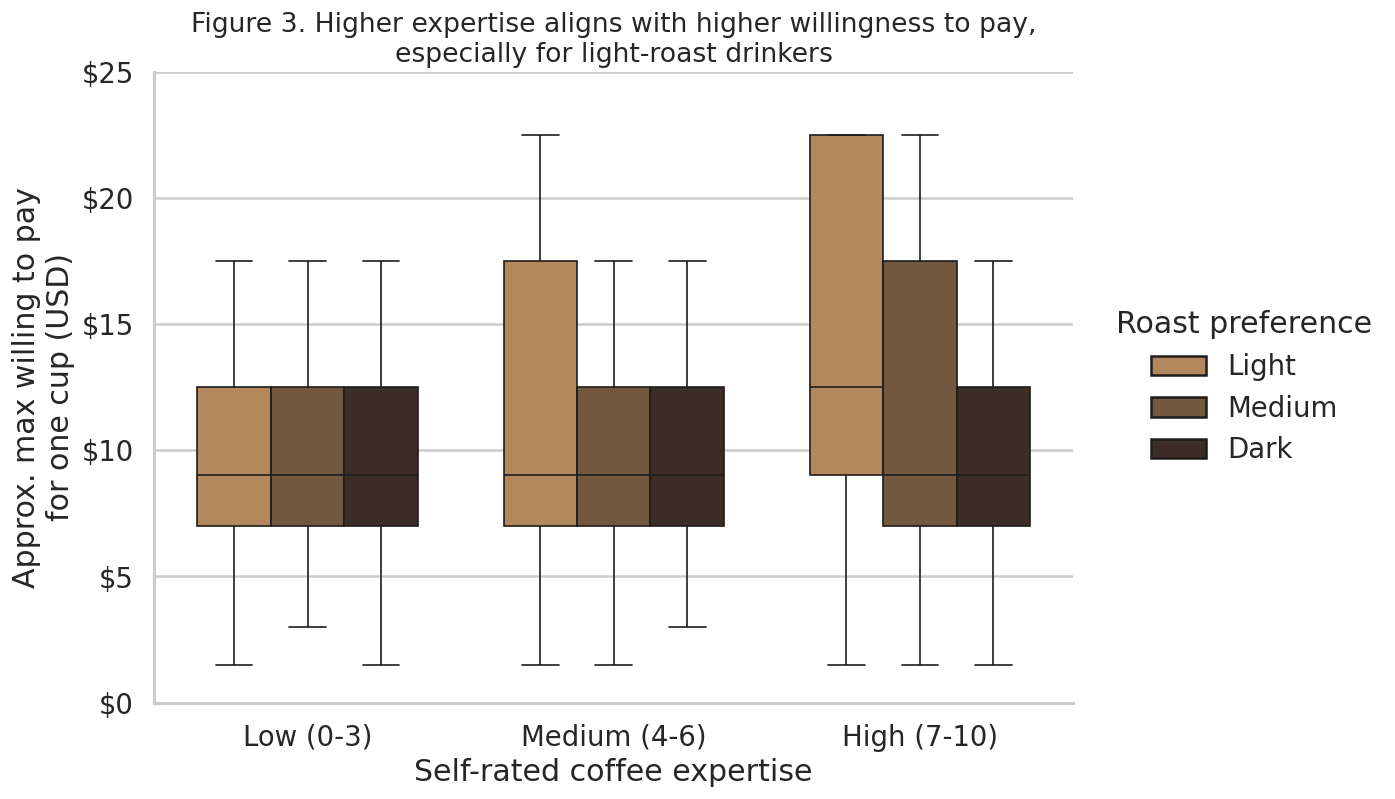

In [30]:
roast_palette = {
    "Light": "#c1884d",
    "Medium": "#7b5738",
    "Dark": "#3f2c23",
}

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    data=fig3_df,
    x="expertise_band",
    y="most_willing_numeric",
    hue="roast_broad",
    order=["Low (0-3)", "Medium (4-6)", "High (7-10)"],
    hue_order=["Light", "Medium", "Dark"],
    palette=roast_palette,
    showfliers=False,
    width=0.72,
    ax=ax,
)

ax.set_title(
    "Figure 3. Higher expertise aligns with higher willingness to pay,\nespecially for light-roast drinkers",
    fontsize=16,
)
ax.set_xlabel("Self-rated coffee expertise")
ax.set_ylabel("Approx. max willing to pay\nfor one cup (USD)")
ax.set_yticks([0, 5, 10, 15, 20, 25])
ax.set_yticklabels([f"${value}" for value in [0, 5, 10, 15, 20, 25]])
ax.legend(title="Roast preference", frameon=False, bbox_to_anchor=(1.02, 0.5), loc="center left")

plt.tight_layout()
plt.show()

## 4. Discussion

**Figure 1.** Across all three work arrangements, the spending distribution shifts toward higher monthly brackets as daily coffee consumption increases. Respondents drinking less than one cup per day are concentrated in the lowest spending categories, while respondents drinking three to four cups per day are much more likely to appear in the `$60+` range. The pattern is especially visible among those who primarily work from home, but the overall direction is consistent across all panels, which suggests that consumption intensity is a basic driver of spending regardless of work arrangement.

**Figure 2.** The bubble chart shows that high-spending respondents are not evenly spread across all taste profiles. Larger and darker bubbles tend to cluster around respondents who use pour-over or espresso at home and who favor pour-over or espresso as drinks. In contrast, latte and regular drip coffee combinations are common but usually have lower shares of high spenders. This indicates that higher spending is associated not only with volume, but also with specialty-style preferences that often require more equipment, ingredients, or willingness to pay for quality.

**Figure 3.** Self-rated expertise is clearly related to willingness to pay. The overall distribution moves upward from the low-expertise group to the high-expertise group, and the highest group shows a noticeably higher median and upper range. Within each expertise level, light-roast drinkers often occupy the highest willingness-to-pay range, especially among respondents who rate themselves as highly knowledgeable. This fits the idea that a more enthusiast-oriented coffee culture values flavor differentiation and is prepared to pay more for it.

Taken together, the three figures suggest that higher coffee spending in this survey is shaped by both **volume** and **enthusiasm**. Some respondents spend more because they drink coffee more often, while others appear to spend more because they participate more deeply in specialty coffee practices and place higher value on nuanced products. However, the data are self-reported and come from a self-selected survey audience, so the results should be interpreted as descriptive relationships within this sample rather than causal claims or population-level conclusions.


## 5. Teamwork

Replace the placeholders below with your group's actual names and contributions before submission. A concise paragraph like the one below matches the assignment requirement:

*Our group divided the project across four workstreams. Member A refined the research question and drafted the introduction. Member B cleaned the data, created the derived variables, and checked missing values. Member C designed the visualizations and helped interpret the main patterns. Member D integrated the notebook, edited the discussion, and verified that the final notebook reproduced the same results as the HTML output. All members reviewed the final write-up and agreed on the final submission.*


## 6. References

1. TidyTuesday. (2024, May 14). *The Great American Coffee Taste Test*. https://github.com/rfordatascience/tidytuesday/tree/main/data/2024/2024-05-14
2. TidyTuesday data file. *coffee_survey.csv*. https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-05-14/coffee_survey.csv
3. Hoffmann, J. (2023). *The Great American Coffee Taste Test* [Video]. YouTube. https://www.youtube.com/watch?v=bMOOQfeloH0
